### Imports

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
import random
import seaborn as sns
import torch

%matplotlib inline

In [ ]:
DIR = "drive/MyDrive/Colab Notebooks/Projects/Collaborative Filtering"

### Overview

In this project, I apply the collaborative filtering technique to predict movie ratings using the movielens dataset. 

Collaborative filtering is a technique used by recommender systems such as Amazon's product recommender or Netflix's suggestions for movies and shows. Essentially, this technique utilizes the habits and tastes of other users in order to predict what content to suggest to other customers with similar interests in a collaborative way.

In this approach, we try to learn the underlying qualities, or embeddings, of the users and movies, in order to compute predictions, which in this case will be the movie ratings. I use matrix factorization, such that there is one matrix containing all user embeddings, and another matrix containing all the movie embeddings. When combining these matrices using a matrix multiplication, we can get the predicted ratings.

The ratings data can be visualized as a matrix, where each entry of the matrix is the rating of a user for a specific movie.

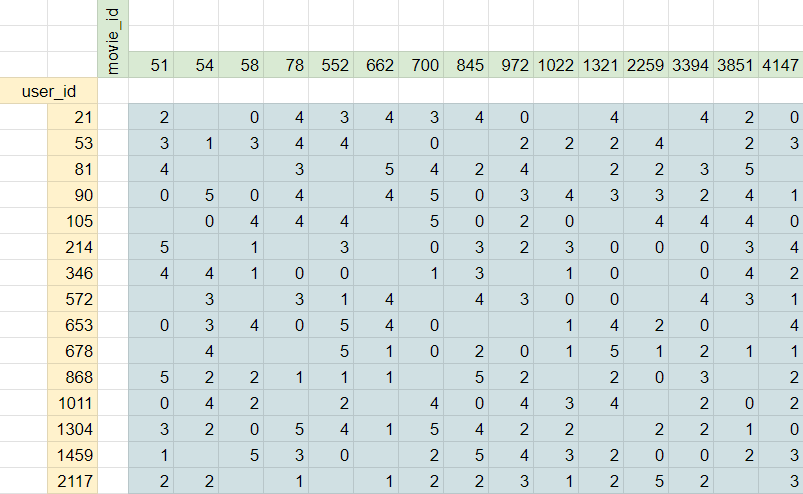

In [ ]:
image1 = Image.open(DIR + "/matrix_ratings_example.png")
image1.show()

The user and movie embeddings are matrices, and each user and movie will have K embedding values (5 in this case). The vector dot product of the user embedding and movie embedding gives the predicted rating. 

The predicted value of a matrix cell for matrix $\hat{A}$ is the vector dot product of the $ith$ user embedding from matrix $U$ with the $jth$ movie embedding from matrix $V$, with the equation as:

\begin{align}
   \hat{A_{ij}} = \sum_{k=1}^K (U_{ik} \cdot V_{kj})
\end{align}

Using gradient descent, these embeddings are updated to be closer to the existing ratings.

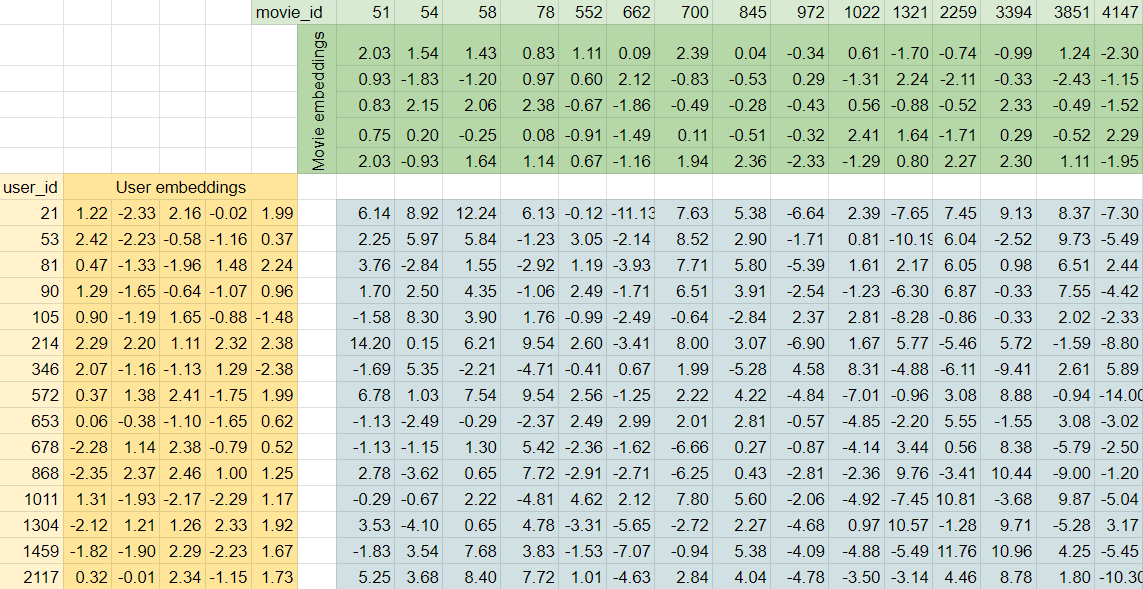

In [ ]:
image2 = Image.open(DIR + "/matrix_example.png")
image2.show()

### Loss Function and Gradients

I use the Mean Squared Error (MSE) as the loss function in this case. It sums up the squared difference of every cell in the matrix $A$ with the predicted matrix $\hat{A}$. Given $N$ as the number of values in the matrix, the equation comes out to:

\begin{align}
   MSE = \frac{1}{N} &\sum_{i=1}^N (A_i - \hat{A_i})^2
\end{align}

Using some built-in functions we don't need to sum over each individual value, so the equation just becomes:

\begin{align}
   MSE = \frac{1}{N} &\sum (A - \hat{A})^2
\end{align}

When it comes to ratings, some users may give consistently high ratings, low ratings, or ratings that are in the middle. In order to account for this bias, we also add a bias for each user ($b_{user}$) and a bias for each movie ($b_{movie}$), and these can also be learned by the model.

\begin{align}
   \hat{A} = U \cdot V + b_{user} + b_{movie}
\end{align}

The loss function can then be written as:

\begin{align}
   MSE = \frac{1}{N} &\sum (A - (U \cdot V + b_{user} + b_{movie}))^2
\end{align}

The gradients with respect to the user embeddings becomes:

\begin{align}
    \frac{\partial MSE}{\partial U} = \frac{-2}{N}(A - \hat{A}) \cdot V
\end{align}

And the gradients respect to the movie embeddings becomes:

\begin{align}
    \frac{\partial MSE}{\partial V} = \frac{-2}{N}(A - \hat{A}) \cdot U
\end{align}

The gradients with respect to the user biases is given by:

\begin{align}
    \frac{\partial MSE}{\partial b_{user}} = \frac{-2}{N}(A - \hat{A})
\end{align}

The gradients with respect to the movie biases is given by:

\begin{align}
    \frac{\partial MSE}{\partial b_{movie}} = \frac{-2}{N}(A - \hat{A})
\end{align}

### Exploratory Data Analysis

In [ ]:
ratings = pd.read_csv(DIR + "/ml-25m/ratings.csv")
print(ratings.head())

   userId  movieId  rating   timestamp
0       1      296     5.0  1147880044
1       1      306     3.5  1147868817
2       1      307     5.0  1147868828
3       1      665     5.0  1147878820
4       1      899     3.5  1147868510


In [ ]:
print(ratings.shape)

(25000095, 4)


In [ ]:
ratings.describe()

,userId,movieId,rating,timestamp
count,2.500010e+07,2.500010e+07,2.500010e+07,2.500010e+07
mean,8.118928e+04,2.138798e+04,3.533854e+00,1.215601e+09
std,4.679172e+04,3.919886e+04,1.060744e+00,2.268758e+08
min,1.000000e+00,1.000000e+00,5.000000e-01,7.896520e+08
25%,4.051000e+04,1.196000e+03,3.000000e+00,1.011747e+09
50%,8.091400e+04,2.947000e+03,3.500000e+00,1.198868e+09
75%,1.215570e+05,8.623000e+03,4.000000e+00,1.447205e+09
max,1.625410e+05,2.091710e+05,5.000000e+00,1.574328e+09


In [ ]:
print(ratings.rating.min())
print(ratings.rating.max())

0.5
5.0


In [ ]:
movies = pd.read_csv(DIR + "/ml-25m/movies.csv")
print(movies.head())

   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  


In [ ]:
print(movies.shape)

(62423, 3)


In [ ]:
unique_genres = set()

for i in range(movies.shape[0]):
  row = movies.iloc[i]
  genres = row.genres
  genres_split = genres.split("|")
  for g in genres_split:
    unique_genres.add(g)

In [ ]:
print(len(unique_genres))
for genre in unique_genres:
  print(genre)

20
Fantasy
Documentary
Comedy
Musical
Film-Noir
Drama
Western
Mystery
Romance
War
Adventure
Sci-Fi
Horror
Crime
IMAX
Thriller
(no genres listed)
Children
Action
Animation


##### Visualize the sparsity of the data

In [ ]:
sub_matrix = torch.full((150, 150), torch.nan)

for i in range(ratings.shape[0]):
  row = ratings.iloc[i]
  user_id = int(row.userId)
  movie_id = int(row.movieId)
  movie_index = movies[movies.movieId==movie_id].index
  rating = row.rating

  if user_id < 150 and movie_index < 150:
    sub_matrix[user_id,movie_index] = 1
  elif user_id >= 150:
    break

<Axes: >

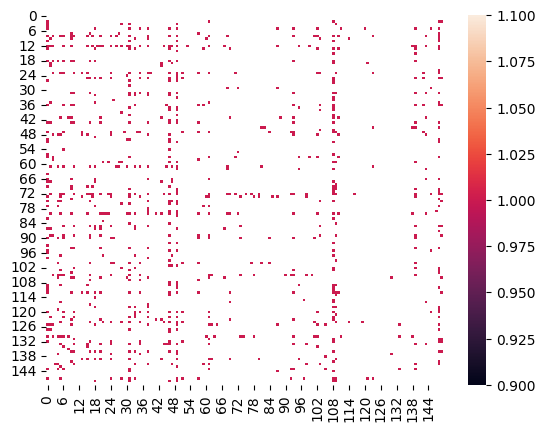

In [ ]:
sns.heatmap(data=sub_matrix)

The data is sparse, as shown in the heatmap. The red dots represent the data that is present, while the white space means missing data.



In [ ]:
print(ratings.shape[0])

25000095


In [ ]:
user_count = ratings.userId.nunique()
movie_count = movies.movieId.nunique()

In [ ]:
print(user_count * movie_count)

10146296843


The rating matrix would have over 10,000,000,000 cells, which is quite large and would make it hard to train. 

To address the sparsity and also to reduce the data size, I will only include the top 2000 most rated movies, and then further reduce the data to only the top 2000 users by number of ratings given. This should result in a rating matrix of 2000 x 2000 = 4,000,000 which is more reasonable.

##### Reduce to top 2000 most rated movies.

In [ ]:
rating_counts = ratings.groupby(['movieId'])['rating'].count()

In [ ]:
rating_counts.sort_values(ascending=False, inplace=True)

In [ ]:
print(rating_counts.head())
print(rating_counts.tail())

movieId
356     81491
318     81482
296     79672
593     74127
2571    72674
Name: rating, dtype: int64
movieId
167308    1
167326    1
167336    1
167338    1
209171    1
Name: rating, dtype: int64


In [ ]:
most_rated_movies_2000 = set([rating_counts.index[i] for i in range(2000)])

In [ ]:
print(most_rated_movies_2000)

{1, 2, 122882, 3, 5, 6, 122886, 7, 9, 10, 11, 122892, 81932, 14, 12, 16, 17, 18, 19, 122900, 21, 22, 23, 122904, 25, 24, 57368, 20, 29, 122906, 31, 32, 122912, 34, 28, 36, 122916, 122918, 39, 122920, 41, 122922, 8228, 44, 45, 122926, 47, 48, 122924, 50, 46, 52, 58, 60, 62, 65, 69, 70, 73, 74, 76, 15, 79, 81, 86, 88, 89, 94, 95, 100, 101, 104, 105, 107, 110, 111, 112, 49272, 139385, 122, 49274, 125, 49278, 49286, 135, 140, 141, 144, 145, 147, 8340, 150, 151, 153, 154, 158, 160, 161, 162, 163, 164, 165, 8360, 168, 8361, 170, 172, 173, 169, 175, 8368, 8371, 180, 8376, 185, 186, 57528, 193, 194, 195, 196, 198, 106696, 203, 204, 207, 208, 215, 216, 218, 222, 223, 224, 225, 227, 230, 231, 232, 233, 234, 235, 236, 33004, 237, 239, 246, 247, 114935, 249, 248, 252, 253, 256, 257, 260, 261, 262, 265, 266, 267, 8464, 272, 273, 276, 277, 280, 281, 282, 106782, 288, 289, 290, 292, 293, 90405, 296, 57640, 300, 303, 305, 306, 307, 308, 314, 315, 316, 317, 318, 319, 322, 57669, 41285, 327, 329, 333, 8

In [ ]:
print(356 in most_rated_movies_2000)
print(318 in most_rated_movies_2000)
print(2571 in most_rated_movies_2000)
print(167308 in most_rated_movies_2000)
print(167326 in most_rated_movies_2000)
print(209171 in most_rated_movies_2000)

True
True
True
False
False
False


In [ ]:
j = 0
for id in most_rated_movies_2000:
  print(movies[movies.movieId==id].title)
  j += 1
  if j >= 10: break

0    Toy Story (1995)
Name: title, dtype: object
1    Jumanji (1995)
Name: title, dtype: object
25053    Mad Max: Fury Road (2015)
Name: title, dtype: object
2    Grumpier Old Men (1995)
Name: title, dtype: object
4    Father of the Bride Part II (1995)
Name: title, dtype: object
5    Heat (1995)
Name: title, dtype: object
25055    Star Wars: Episode VII - The Force Awakens (2015)
Name: title, dtype: object
6    Sabrina (1995)
Name: title, dtype: object
8    Sudden Death (1995)
Name: title, dtype: object
9    GoldenEye (1995)
Name: title, dtype: object


In [ ]:
movies_copy = movies.copy()

In [ ]:
drop_indices = []
for index in range(movies_copy.shape[0]):
  movie_id = movies_copy.iloc[index].movieId
  if movie_id not in most_rated_movies_2000:
    drop_indices.append(index)

In [ ]:
print(movies[movies.movieId==167308].index in drop_indices)
print(movies[movies.movieId==167326].index in drop_indices)
print(movies[movies.movieId==209171].index in drop_indices)

True
True
True


In [ ]:
movies_copy.drop(drop_indices, inplace=True)
print(movies_copy.shape)

(2000, 3)


In [ ]:
ratings_top_2000_movies = ratings.merge(movies_copy, on='movieId')

In [ ]:
print(ratings.shape)
print(ratings_top_2000_movies.shape)

print(ratings_top_2000_movies.userId.nunique())
print(ratings_top_2000_movies.movieId.nunique())

(25000095, 4)
(19209421, 6)
162531
2000


##### Average movie ratings

In [ ]:
avg_rating_overall = ratings_top_2000_movies.rating.mean()
print(avg_rating_overall)

3.614377913837174


In [ ]:
avg_ratings = ratings_top_2000_movies.groupby(['movieId'], as_index=False)['rating'].mean()

In [ ]:
avg_ratings.sort_values(by='rating', ascending=False, inplace=True)

##### Top 10 movies by average rating

In [ ]:
top_10_movies = [movie_id for movie_id in avg_ratings[0:10].movieId]

In [ ]:
for i in range(10):
  id = top_10_movies[i]
  print(movies[movies.movieId==id].title)
  print(avg_ratings.iloc[i])

314    Shawshank Redemption, The (1994)
Name: title, dtype: object
movieId    318.000000
rating       4.413576
Name: 152, dtype: float64
840    Godfather, The (1972)
Name: title, dtype: object
movieId    858.000000
rating       4.324336
Name: 331, dtype: float64
49    Usual Suspects, The (1995)
Name: title, dtype: object
movieId    50.000000
rating      4.284353
Name: 35, dtype: float64
1190    Godfather: Part II, The (1974)
Name: title, dtype: object
movieId    1221.000000
rating        4.261759
Name: 470, dtype: float64
1930    Seven Samurai (Shichinin no samurai) (1954)
Name: title, dtype: object
movieId    2019.000000
rating        4.254769
Name: 736, dtype: float64
522    Schindler's List (1993)
Name: title, dtype: object
movieId    527.000000
rating       4.247579
Name: 242, dtype: float64
1173    12 Angry Men (1957)
Name: title, dtype: object
movieId    1203.000000
rating        4.243014
Name: 454, dtype: float64
883    Rear Window (1954)
Name: title, dtype: object
movieId    90

##### Bottom 10 movies by average rating

In [ ]:
avg_ratings_asc = avg_ratings.sort_values(by='rating', ascending=True, inplace=False)

In [ ]:
bottom_10_movies = [movie_id for movie_id in avg_ratings_asc[0:10].movieId]

In [ ]:
for i in range(10):
  id = bottom_10_movies[i]
  print(movies[movies.movieId==id].title)
  print(avg_ratings_asc.iloc[i])

3494    Battlefield Earth (2000)
Name: title, dtype: object
movieId    3593.000000
rating        1.578374
Name: 1142, dtype: float64
1643    Home Alone 3 (1997)
Name: title, dtype: object
movieId    1707.000000
rating        1.871245
Name: 658, dtype: float64
1501    Speed 2: Cruise Control (1997)
Name: title, dtype: object
movieId    1556.000000
rating        1.910918
Name: 612, dtype: float64
1345    Grease 2 (1982)
Name: title, dtype: object
movieId    1381.000000
rating        1.970503
Name: 573, dtype: float64
2552    Superman IV: The Quest for Peace (1987)
Name: title, dtype: object
movieId    2643.000000
rating        2.010652
Name: 914, dtype: float64
540    Super Mario Bros. (1993)
Name: title, dtype: object
movieId    546.000000
rating       2.061534
Name: 256, dtype: float64
1451    Anaconda (1997)
Name: title, dtype: object
movieId    1499.000000
rating        2.079517
Name: 602, dtype: float64
722    Barb Wire (1996)
Name: title, dtype: object
movieId    737.000000
rating 

##### Reduce the data to only include top 2000 users with most ratings given.

In [ ]:
user_rating_counts = ratings_top_2000_movies.groupby(['userId'], as_index=False).count()

In [ ]:
print(user_rating_counts.shape)

(162531, 2)


In [ ]:
user_rating_counts['ratings_count'] = user_rating_counts['movieId']
user_rating_counts.drop(columns=['movieId', 'rating', 'timestamp', 'title', 'genres'], inplace=True)

In [ ]:
user_rating_counts.sort_values(by='ratings_count', ascending=False, inplace=True)

In [ ]:
print(user_rating_counts.head())

        userId  ratings_count
107642  107650           1996
57543    57548           1987
72309    72315           1909
20050    20055           1824
162505  162516           1791


In [ ]:
print(user_rating_counts.tail())

        userId  ratings_count
55659    55664              1
10858    10861              1
135063  135073              1
103040  103048              1
159166  159177              1


In [ ]:
top_2000_rating_users = user_rating_counts[0:2000]

In [ ]:
print(top_2000_rating_users.shape)

(2000, 2)


In [ ]:
top_2000_rating_users_set = set()

j = 0
for user_id in top_2000_rating_users.userId:
  top_2000_rating_users_set.add(user_id)
  j += 1
  if j >= 2000:
    break

In [ ]:
new_df = ratings_top_2000_movies[ratings_top_2000_movies['userId'].isin(top_2000_rating_users_set)]

In [ ]:
print(new_df.shape)

(1845202, 6)


In [ ]:
print(new_df.userId.nunique())
print(new_df.movieId.nunique())

2000
2000


In [ ]:
print(new_df.head())

     userId  movieId  rating   timestamp                title  \
207     426      296     4.5  1281844645  Pulp Fiction (1994)   
261     548      296     4.5  1431644890  Pulp Fiction (1994)   
362     757      296     3.5  1184013514  Pulp Fiction (1994)   
405     847      296     4.0  1129270862  Pulp Fiction (1994)   
468     983      296     5.0  1076866714  Pulp Fiction (1994)   

                          genres  
207  Comedy|Crime|Drama|Thriller  
261  Comedy|Crime|Drama|Thriller  
362  Comedy|Crime|Drama|Thriller  
405  Comedy|Crime|Drama|Thriller  
468  Comedy|Crime|Drama|Thriller  


In [ ]:
A_size = 2000 * 2000
print(new_df.shape[0] / A_size)

0.4613005


##### About 46% of the matrix has ratings given, which is less sparse than the full dataset. The matrix shape is also smaller, making it easier to train.

##### Counts by ratings histogram

In [ ]:
rating_counts = new_df.groupby(['rating'], as_index=False).count()

rating_counts['ratings_count'] = rating_counts['movieId']
rating_counts.drop(columns=['movieId', 'userId', 'timestamp', 'title', 'genres'], inplace=True)

In [ ]:
print(rating_counts)

   rating  ratings_count
0     0.5          30029
1     1.0          54198
2     1.5          42891
3     2.0         143130
4     2.5         144462
5     3.0         384973
6     3.5         309415
7     4.0         443806
8     4.5         142250
9     5.0         150048


<Axes: xlabel='rating', ylabel='ratings_count'>

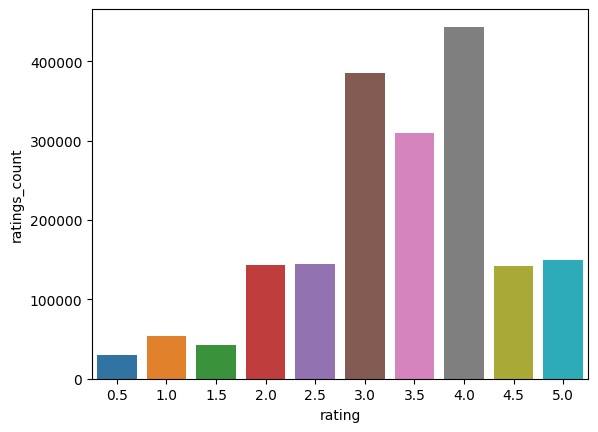

In [ ]:
sns.barplot(x=rating_counts.rating, y=rating_counts.ratings_count)

##### Number of ratings given by users

In [ ]:
new_user_rating_counts = new_df.groupby(['userId'], as_index=False).count()

In [ ]:
new_user_rating_counts['ratings_given'] = new_user_rating_counts['movieId']
new_user_rating_counts.drop(columns=['movieId', 'rating', 'timestamp', 'title', 'genres'], inplace=True)

In [ ]:
print(new_user_rating_counts.head())

   userId  ratings_given
0     426            751
1     548           1069
2     626            920
3     757            766
4     847           1068


<Axes: xlabel='ratings_given', ylabel='Count'>

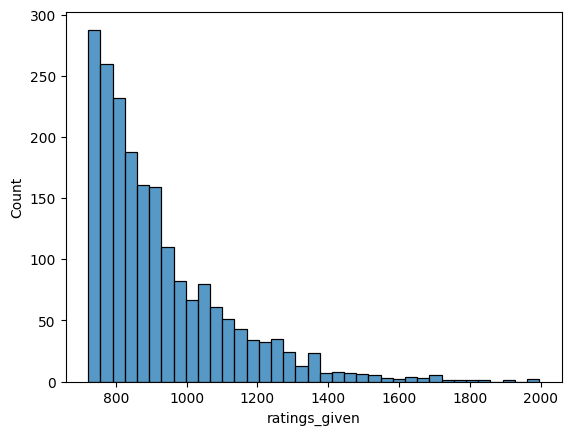

In [ ]:
sns.histplot(data=new_user_rating_counts, x='ratings_given')

### Train-test split

In [ ]:
U_size = 2000 # User embedding matrix
V_size = 2000 # Movie embedding matrix
K = 5         # Number of latent factors, embeddings

In [ ]:
def get_train_test_split(df, m=2000, n=2000, split=0.9, ensure_uniques=True):
  N = len(df)
  indices = list(range(0, N))
  random.shuffle(indices)
  end = int(N*split)

  train_df = df.iloc[indices[0:end]]
  test_df = df.iloc[indices[end:N]]

  # Ensure there are m unique userId's and n movieId's in the train data.
  if ensure_uniques:
    if train_df.userId.nunique() != m or train_df.movieId.nunique() != n:
      return get_train_test_split(df)

  return train_df, test_df

In [ ]:
train, test = get_train_test_split(new_df)

In [ ]:
print(train.userId.nunique())
print(train.movieId.nunique())

2000
2000


In [ ]:
print(test.userId.nunique())
print(test.movieId.nunique())

2000
2000


In [ ]:
print(train.shape)
print(test.shape)

(1660681, 6)
(184521, 6)


### Model and training

In [ ]:
class CFModel:

  def __init__(self, U, V, b_user, b_movie, lr=0.2, epochs=1000):
    self.U = U
    self.V = V    
    self.b_user = b_user
    self.b_movie = b_movie
    self.lr = lr
    self.epochs = epochs

  def forward(self):
    return self.U@self.V.T + self.b_user + self.b_movie.T

  def calc_loss(self, A, A_pred, size):
    sum_of_squares = torch.nansum((A - A_pred)**2)
    return (1.0 / size) * sum_of_squares

  def calc_grad(self, A, A_pred, size):
    U_grad = torch.nan_to_num(A - A_pred)@self.V * (-2.0/size)
    V_grad = torch.nan_to_num(A.T - A_pred.T)@self.U * (-2.0/size)
    # Sum across all contributions for the biases
    b_user_grad = torch.unsqueeze(torch.sum((torch.nan_to_num(A - A_pred)), 1), 1) * (-2.0/size)
    b_movie_grad = torch.unsqueeze(torch.sum((torch.nan_to_num(A.T - A_pred.T)), 1), 1) * (-2.0/size)

    return U_grad, V_grad, b_user_grad, b_movie_grad

  def optimize(self, A_train, A_test, train_size, test_size):
    for epoch in range(self.epochs):
      A_pred = self.forward()
      U_grad, V_grad, b_user_grad, b_movie_grad = self.calc_grad(A_train, A_pred, train_size)

      self.U -= self.lr*torch.nan_to_num(U_grad)
      self.V -= self.lr*torch.nan_to_num(V_grad)
      self.b_user -= self.lr*torch.nan_to_num(b_user_grad)
      self.b_movie -= self.lr*torch.nan_to_num(b_movie_grad)

      if (epoch + 1) % (self.epochs / 10) == 0:
        train_loss = self.calc_loss(A_train, A_pred, train_size)        
        test_loss = self.calc_loss(A_test, A_pred, test_size)
        print("epoch {}, training loss={} test loss={}".format(epoch+1, train_loss, test_loss))

  def get_recommended_movies(self, embedding, movies, index_to_id_map):
    # Given some embedding (user or movie), return the top 10 most 
    # similar movies.
    class RatingPair:
      def __init__(self, movie_idx, sim_score):
        self.movie_idx = movie_idx
        self.sim_score = sim_score

    similarities = embedding@self.V.T
    movie_pairs = []
    
    for j in range(self.V.shape[0]):
      sim_score = similarities[j]
      pair = RatingPair(j, sim_score)
      movie_pairs.append(pair)

    res = sorted(movie_pairs, key=lambda x: x.sim_score, reverse=True)
    
    top_10 = []
    for i in range(10):
      pair = res[i]
      movie_id = index_to_id_map.get(pair.movie_idx)
      top_10.append(movies[movies.movieId==movie_id].title)
      
    return top_10

In [ ]:
movie_id_to_index = {}
index_to_movie_id = {}
unique_movies = new_df.movieId.unique()

for i in range(2000):
  movie_id = unique_movies[i]
  movie_id_to_index[movie_id] = i
  index_to_movie_id[i] = movie_id

In [ ]:
user_id_to_index = {}
unique_users = new_df.userId.unique()

for i in range(2000):
  user_id = unique_users[i]
  user_id_to_index[user_id] = i

In [ ]:
U = torch.rand(2000, 5) - 0.5
V = torch.rand(2000, 5) - 0.5
b_user = torch.zeros(2000, 1)
b_movie = torch.zeros(2000, 1)

In [ ]:
train_size = train.shape[0]
test_size = test.shape[0]

In [ ]:
A_train = torch.full((2000, 2000), torch.nan)

In [ ]:
for i in range(train.shape[0]):
  row = train.iloc[i]
  user_idx = user_id_to_index[int(row.userId)]
  movie_idx = movie_id_to_index[int(row.movieId)]
  rating = row.rating

  A_train[user_idx,movie_idx] = rating

In [ ]:
A_test = torch.full((2000, 2000), torch.nan)

In [ ]:
for i in range(test.shape[0]):
  row = test.iloc[i]
  user_idx = user_id_to_index[int(row.userId)]
  movie_idx = movie_id_to_index[int(row.movieId)]
  rating = row.rating

  A_test[user_idx,movie_idx] = rating

In [ ]:
model = CFModel(U, V, b_user, b_movie, lr=0.1, epochs=10000)

In [ ]:
model.optimize(A_train, A_test, train_size, test_size)

epoch 1000, training loss=8.168608665466309 test loss=8.187605857849121
epoch 2000, training loss=5.567161560058594 test loss=5.5851922035217285
epoch 3000, training loss=3.9163661003112793 test loss=3.9326372146606445
epoch 4000, training loss=2.8596107959747314 test loss=2.873922348022461
epoch 5000, training loss=2.175893783569336 test loss=2.188333034515381
epoch 6000, training loss=1.7278472185134888 test loss=1.7386243343353271
epoch 7000, training loss=1.429785132408142 test loss=1.439144492149353
epoch 8000, training loss=1.2280303239822388 test loss=1.2362096309661865
epoch 9000, training loss=1.0887799263000488 test loss=1.0959928035736084
epoch 10000, training loss=0.9906127452850342 test loss=0.997042179107666


In [ ]:
print(model.U[0:6])
print(model.V[0:6])

tensor([[-0.1643, -0.0539,  0.3574,  0.0071, -0.2868],
        [ 0.4540, -0.4029,  0.2189,  0.3116,  0.0213],
        [ 0.3952, -0.1608,  0.2720, -0.2091,  0.3361],
        [ 0.3695, -0.1807, -0.0345, -0.3088, -0.2301],
        [ 0.0440,  0.4156,  0.0601, -0.0523, -0.2573],
        [-0.0190,  0.3761, -0.0498, -0.4568,  0.0204]])
tensor([[-0.3976,  0.3864, -0.0799, -0.3767, -0.2158],
        [-0.0028, -0.3727,  0.0512, -0.0090, -0.4036],
        [ 0.2413,  0.4243, -0.3056,  0.4646, -0.3087],
        [ 0.2154, -0.2783,  0.0424,  0.4138, -0.1377],
        [ 0.3234,  0.2103,  0.1887,  0.1980, -0.1393],
        [ 0.2469,  0.0521, -0.1704, -0.1674,  0.2552]])


In [ ]:
print(model.b_user[0:6])
print(model.b_movie[0:6])

tensor([[0.9432],
        [1.6557],
        [1.3089],
        [1.4223],
        [1.1645],
        [1.5364]])
tensor([[2.8303],
        [1.3120],
        [1.2642],
        [1.8424],
        [1.3556],
        [1.4911]])


##### Top 10 recommended movies

In [ ]:
movie_index = 0

movie = movies[movies.movieId==index_to_movie_id.get(movie_index)].title
print("Similar movies for " + movie)

embedding = model.V[movie_index]
similar_movies = model.get_recommended_movies(embedding, movies, index_to_movie_id)

for title in similar_movies:
  print(title)

292    Similar movies for Pulp Fiction (1994)
Name: title, dtype: object
3007    River Runs Through It, A (1992)
Name: title, dtype: object
20    Get Shorty (1995)
Name: title, dtype: object
3172    Hard-Boiled (Lat sau san taam) (1992)
Name: title, dtype: object
292    Pulp Fiction (1994)
Name: title, dtype: object
2377    Jumpin' Jack Flash (1986)
Name: title, dtype: object
2474    King and I, The (1956)
Name: title, dtype: object
1793    Godzilla (1998)
Name: title, dtype: object
7192    EuroTrip (2004)
Name: title, dtype: object
19885    Pacific Rim (2013)
Name: title, dtype: object
1179    Star Wars: Episode VI - Return of the Jedi (1983)
Name: title, dtype: object


In [ ]:
movie_index2 = 15

movie2 = movies[movies.movieId==index_to_movie_id.get(movie_index2)].title
print("Similar movies for " + movie2)

embedding2 = model.V[movie_index2]
similar_movies2 = model.get_recommended_movies(embedding2, movies, index_to_movie_id)

for title in similar_movies2:
  print(title)

3352    Similar movies for Good Morning, Vietnam (1987)
Name: title, dtype: object
9437    Charlie and the Chocolate Factory (2005)
Name: title, dtype: object
1803    Perfect Murder, A (1998)
Name: title, dtype: object
2356    Varsity Blues (1999)
Name: title, dtype: object
4362    Adventures of Baron Munchausen, The (1988)
Name: title, dtype: object
1723    Wild Things (1998)
Name: title, dtype: object
20678    Secret Life of Walter Mitty, The (2013)
Name: title, dtype: object
510    Remains of the Day, The (1993)
Name: title, dtype: object
12761    Role Models (2008)
Name: title, dtype: object
3708    What About Bob? (1991)
Name: title, dtype: object
1229    Great Escape, The (1963)
Name: title, dtype: object


In [ ]:
movie_index3 = 50

movie3 = movies[movies.movieId==index_to_movie_id.get(movie_index3)].title
print("Similar movies for " + movie3)

embedding3 = model.V[movie_index3]
similar_movies3 = model.get_recommended_movies(embedding3, movies, index_to_movie_id)

for title in similar_movies3:
  print(title)

522    Similar movies for Schindler's List (1993)
Name: title, dtype: object
2096    Strangers on a Train (1951)
Name: title, dtype: object
3575    Eraserhead (1977)
Name: title, dtype: object
12901    Curious Case of Benjamin Button, The (2008)
Name: title, dtype: object
522    Schindler's List (1993)
Name: title, dtype: object
3580    For a Few Dollars More (Per qualche dollaro in...
Name: title, dtype: object
1858    West Side Story (1961)
Name: title, dtype: object
18108    Dictator, The (2012)
Name: title, dtype: object
484    Made in America (1993)
Name: title, dtype: object
1239    Patton (1970)
Name: title, dtype: object
1832    Pi (1998)
Name: title, dtype: object
